# Case study: ZESTA zf5 Stereo-seq sp-SVC

## Notebook Guide

1. Set `REVISE_TACCO_DATA_ROOT` to the data root used by the preparation and
   reconstruction commands. Place `zf5_stereoseq.h5ad` and `zf5_scRNA.h5ad`
   under its `raw/zesta_zf5/` directory before running the notebook.
2. Run the explicit preparation cell, then run the formal `sp-SVC` command.
3. Inspect the three independently fitted expression-space UMAP panels.

**Question:** How does the formal sp-SVC output compare with its paired inputs in
independent expression-space panels?

**Method:** Prepare the official counts, run `reconstruct.py`, and fit each UMAP
independently with the formal `svc.obs["celltype_new"]` labels aligned to raw ST.

**Direct observation:** The panels show within-source structure only; their axes are
independently fitted.

The Phase 1 snapshot (historical figure) in cell 8 is retained; the streamlined
code has not been rerun in this checkout.


In [ ]:
import os
from pathlib import Path
import subprocess
import sys

for key in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
):
    os.environ[key] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["MPLBACKEND"] = "Agg"
SEED = 42

import anndata as ad
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
CASE_DIR = REPO_ROOT / "reproduce/case/stereo_seq"
TACCO_CASE_DIR = REPO_ROOT / "reproduce/case/tacco"
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(TACCO_CASE_DIR))

from notebook_utils import independent_umaps, plot_independent_panels

DATA_ROOT = Path(os.environ["REVISE_TACCO_DATA_ROOT"]).expanduser().resolve()
PREPARE_SCRIPT = CASE_DIR / "prepare_zesta_zf5.py"
RUN_ENV = os.environ.copy()
RUN_ENV["PYTHONPATH"] = str(REPO_ROOT)
RUN_ENV["MPLBACKEND"] = "Agg"
RUN_ENV["REVISE_TACCO_DATA_ROOT"] = str(DATA_ROOT)


## 1. Prepare the paired official H5ADs


In [ ]:
subprocess.run(
    [sys.executable, str(PREPARE_SCRIPT)],
    cwd=REPO_ROOT,
    env=RUN_ENV,
    check=True,
)
CASE_ROOT = DATA_ROOT / "prepared/zesta_zf5"
ST_PATH = CASE_ROOT / "zf5_stereoseq_counts.h5ad"
REFERENCE_PATH = CASE_ROOT / "zf5_scRNA_counts.h5ad"

raw_st = ad.read_h5ad(ST_PATH)
reference = ad.read_h5ad(REFERENCE_PATH)


## 2. Run the formal TACCO-backed REVISE sp-SVC route


In [ ]:
CONFIG_PATH = CASE_DIR / "configs/ZESTA_zf5_sp_SVC.yaml"
command = [
    sys.executable,
    str(REPO_ROOT / "reconstruct.py"),
    "--config",
    str(CONFIG_PATH),
]
subprocess.run(command, cwd=DATA_ROOT, env=RUN_ENV, check=True)


In [ ]:
SVC_PATH = DATA_ROOT / "results/zesta_zf5/ZESTA_zf5_sp_SVC.h5ad"
svc = ad.read_h5ad(SVC_PATH)


## 3. Independent expression-space UMAPs

Reference cells, raw Stereo-seq bins, and reconstructed SVCs are fitted on their
own gene axes with the same seeded recipe:
`normalize_total(1e4) -> log1p -> <=2,000 HVGs -> <=30 PCs -> 15-neighbor UMAP`.
The raw-ST panel uses the source count matrix and the exact formal
`svc.obs["celltype_new"]` labels aligned by observation name. Independently fitted
UMAP axes, coordinates, orientation, scale, and origin are not comparable across
panels.


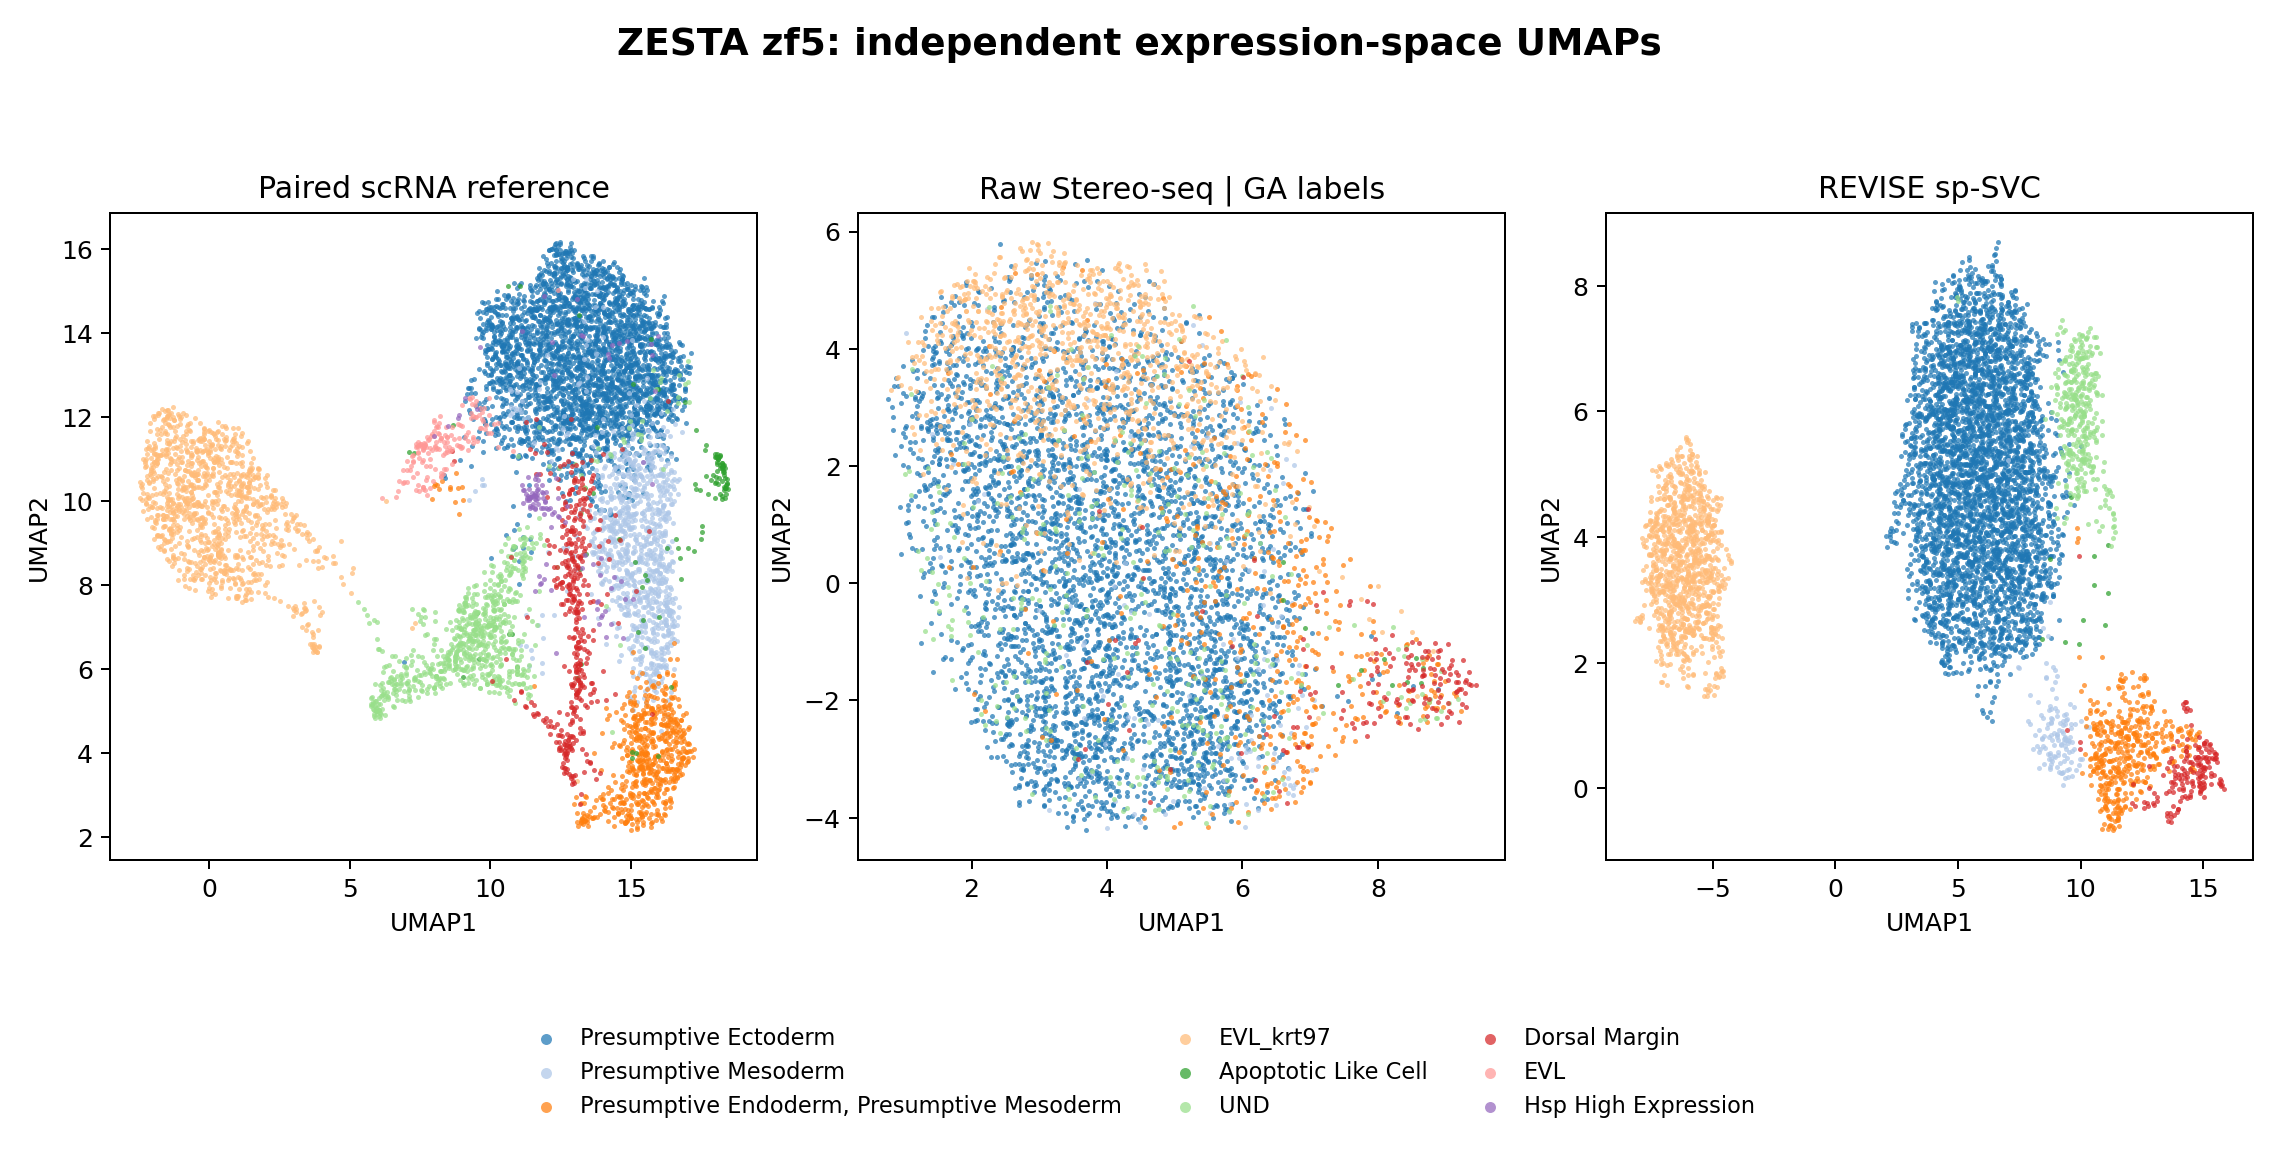

In [ ]:
raw_for_umap = raw_st.copy()
formal_ga_labels = svc.obs["celltype_new"].reindex(raw_for_umap.obs_names)
embeddings = independent_umaps(
    {"reference": reference, "raw_st": raw_for_umap, "svc": svc},
    categorical_labels={
        "reference": reference.obs["celltype_new"],
        "raw_st": formal_ga_labels,
        "svc": svc.obs["celltype_new"],
    },
    seed=SEED,
)
fig = plot_independent_panels(
    embeddings,
    ["reference", "raw_st", "svc"],
    titles={
        "reference": "Paired scRNA reference",
        "raw_st": "Raw Stereo-seq | formal GA labels",
        "svc": "REVISE sp-SVC",
    },
    figsize=(13.2, 6.4),
)
panel_axes = fig.axes[:3]
legend_handles, legend_labels = panel_axes[0].get_legend_handles_labels()
for ax in panel_axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    ax.set_box_aspect(1)
    ax.title.set_fontsize(12)
fig.suptitle(
    "ZESTA zf5: independent expression-space UMAPs",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=3,
    frameon=False,
    fontsize=9,
    markerscale=2.2,
    columnspacing=1.8,
    handletextpad=0.5,
)
fig.tight_layout(rect=(0.02, 0.20, 0.98, 0.93), w_pad=1.3)
plt.show()


## Interpretation boundary

This figure is a retained historical execution snapshot, not a new run in this
checkout and not an independent accuracy benchmark. Each UMAP is fitted separately
and supports within-source structure only. The raw Stereo-seq coordinates come from
counts, while their colors are the formal run's reference-guided `celltype_new`
assignments. The strength and joint-graph settings are transferred from the cited
Slide-seq colon workflow and have not been tuned for ZESTA.
